# Combinatorial CoWork 2026 — Notebook 00: Workflow contract

Audience:
- Commutative algebraists and computation-oriented workshop participants.

Learning goals:
- Verify the Julia kernel and `TamerOp` environment.
- See the core workflow contract: synthetic source object -> `encode(...)` -> `EncodingResult` -> invariant/visual summary.
- Learn core notebook habits of this library

In [ ]:
NOTEBOOK_STEM = "00_kernel_smoke_and_workflow_contract"

_TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

if !isdefined(Main, :TamerOp)
    try
        @eval Main using TamerOp
    catch
        Base.include(Main, joinpath(_TO_ROOT, "src", "TamerOp.jl"))
    end
end

TO = Main.TamerOp



# CM = TO.CoreModules
# OPT = TO.Options

# when repeated queries on the same encoded object make reuse worthwhile:
# sc = TO.SessionCache()

TamerOp

## 1. Build the smallest useful synthetic source object

We start with one axis-aligned box bar in `R^2`. This is small enough to run instantly but already exercises the same workflow surface used later for more algebraic examples.


In [2]:
SD = TO.SyntheticData

box = SD.box_bar_fringe(
    bars=[([0.0, 0.0], [1.0, 1.0])],
    # field=CM.QQField(),
)

SyntheticBoxFringe
  ambient_dim: 2
  nupsets: 1
  ndownsets: 1
  matrix_size: (1, 1)
  field: TamerOp.CoreModules.CoeffFields.QQField()

`matrix_size = (r, c)` is the size of the box-fringe coefficient matrix `phi`: `r` downsets/relations by `c` upsets/generators.

A quick distinction:

- `typeof(box)` is the Julia runtime type, here `SyntheticBoxFringe`.
- `kind = :synthetic_box_fringe` is the user-facing semantic label that appears in validation and summary output.

So the type is the concrete implementation object, while the `kind` is the notebook-friendly category name for that object family.


In [ ]:
box_check=SD.check_synthetic_box_fringe(box)

(kind = :synthetic_box_fringe, valid = true, ambient_dim = 2, issues = String[])

## 2. Encode once, then inspect the workflow result in small steps

Once a source object is encoded, we should be able to ask mathematical questions without dropping into storage-shaped internals. We keep the first inspection pass very explicit:

1. build the `EncodingResult`
2. inspect it generically
3. inspect it through the owner-local summary helper
4. use semantic accessors to reach the encoding map and its geometry


In [4]:
# enc = TO.encode(box; cache=sc)
enc = TO.encode(box)


EncodingResult
  poset_type: TamerOp.ZnEncoding.SignaturePoset{1, 1}
  module_type: TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}
  encoding_map_type: TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}
  backend: pl_backend
  compiled: true
  has_cohomology: true
  has_presentation: true
  module_dims: [0, 0, 1, 0]

`enc` is now an `EncodingResult`, the canonical workflow object returned by `encode(...)`. We first inspect it through the generic cross-library hook.


In [5]:
encoding_description = TO.describe(enc)


(kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 1, 0])

The owner-local summary helper is `result_summary(...)`. It is more specific to workflow result wrappers, while `describe(...)` is the generic habit that works across the library.

In the `describe(enc)` output above:

- `compiled = true` means the encoding map stored in the result is already a compiled classifier object, ready for fast region and query work.
- `has_cohomology = true` means the workflow result still carries the pushed-down fringe/cohomological provenance object, not just the finite module.
- `has_presentation = true` means the result still remembers the presentation/provenance data from which the encoding was built.
- `module_dims = [0, 0, 1, 0]` means the encoded finite-poset module has dimensions `0, 0, 1, 0` at the four vertices of the encoding poset.


In [6]:
encoding_result_summary = TO.result_summary(enc)

(kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 1, 0])

Now use semantic accessors instead of field inspection. The encoding map `pi` is the geometric/query object we will reuse for invariants and visuals.

Here `encoding_axes(pi)` means the semantic coordinate axes attached to the encoding map. In this small 2-parameter example, that means the x- and y-coordinate grids that label the encoded geometry. They are useful for inspection and plotting, but they are not the core classification contract itself.


In [7]:
pi = TO.encoding_map(enc)

(; encoding_axes=TO.encoding_axes(pi),
   available_visuals=TO.available_visuals(pi))


(encoding_axes = ([0.0, 1.0], [0.0, 1.0]), available_visuals = (:regions, :region_labels, :query_overlay))

## 3. One invariant and two explicit visual summaries

First compute one invariant. Then build two visual specs from it and from the encoding map. The point of this section is to teach the visual object flow explicitly, not to hide it behind rendering machinery.


In [8]:
#opts = OPT.InvariantOptions(threads=false)

#rank = TO.rank_invariant(enc; opts=opts, cache=sc)
rank = TO.rank_invariant(enc)

RankInvariantResult
  nentries: 1
  nnonzero: 1
  store_zeros: false
  nvertices: 4
  poset_type: TamerOp.ZnEncoding.SignaturePoset{1, 1}

`visual_spec(obj; kind=...)` builds a backend-agnostic description of what to draw. It is the visual plan, not the rendered figure itself.

`visual_summary(spec)` gives a cheap textual/structured summary of that visual plan, which is useful in notebooks even when no renderer is active.

Here:

- `kind = :rank_heatmap` asks for a heatmap-style view of the rank invariant,
- `kind = :regions` asks for a region view of the encoding map.

Later, the same objects can be exported with `save_visuals(...)`.


In [9]:
rank_spec = TO.Visualization.visual_spec(rank; kind=:rank_heatmap)
region_spec = TO.Visualization.visual_spec(pi; kind=:regions)

(; rank_summary=TO.describe(rank),
   rank_visual_summary=TO.Visualization.visual_summary(rank_spec),
   region_visual_summary=TO.Visualization.visual_summary(region_spec))

(rank_summary = (kind = :rank_invariant, nentries = 1, nnonzero = 1, store_zeros = false, nvertices = 4, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}), rank_visual_summary = (kind = :visualization_spec, visual_kind = :rank_heatmap, title = "Rank invariant heatmap", subtitle = "rank values on comparable poset pairs", nlayers = 1, npanels = 0, layer_types = (:HeatmapLayer,), axes = (xlabel = "target region b", ylabel = "source region a", xlimits = (0.5, 4.5), ylimits = (0.5, 4.5), zlabel = "z", zlimits = nothing, aspect = :auto, xticks = ([1, 2, 3, 4], ["1", "2", "3", "4"]), yticks = ([1, 2, 3, 4], ["1", "2", "3", "4"])), metadata = (object = :rank_invariant, nvertices = 4, nstored = 1, figure_size = (720, 620), legend_position = :none), legend_visible = false, interaction = (hover = false, labels = false, clicks = false, widgets = (), notebook = :summary_card)), region_visual_summary = (kind = :visualization_spec, visual_kind = :regions, title = "Box encoding", subtitle = "", nl

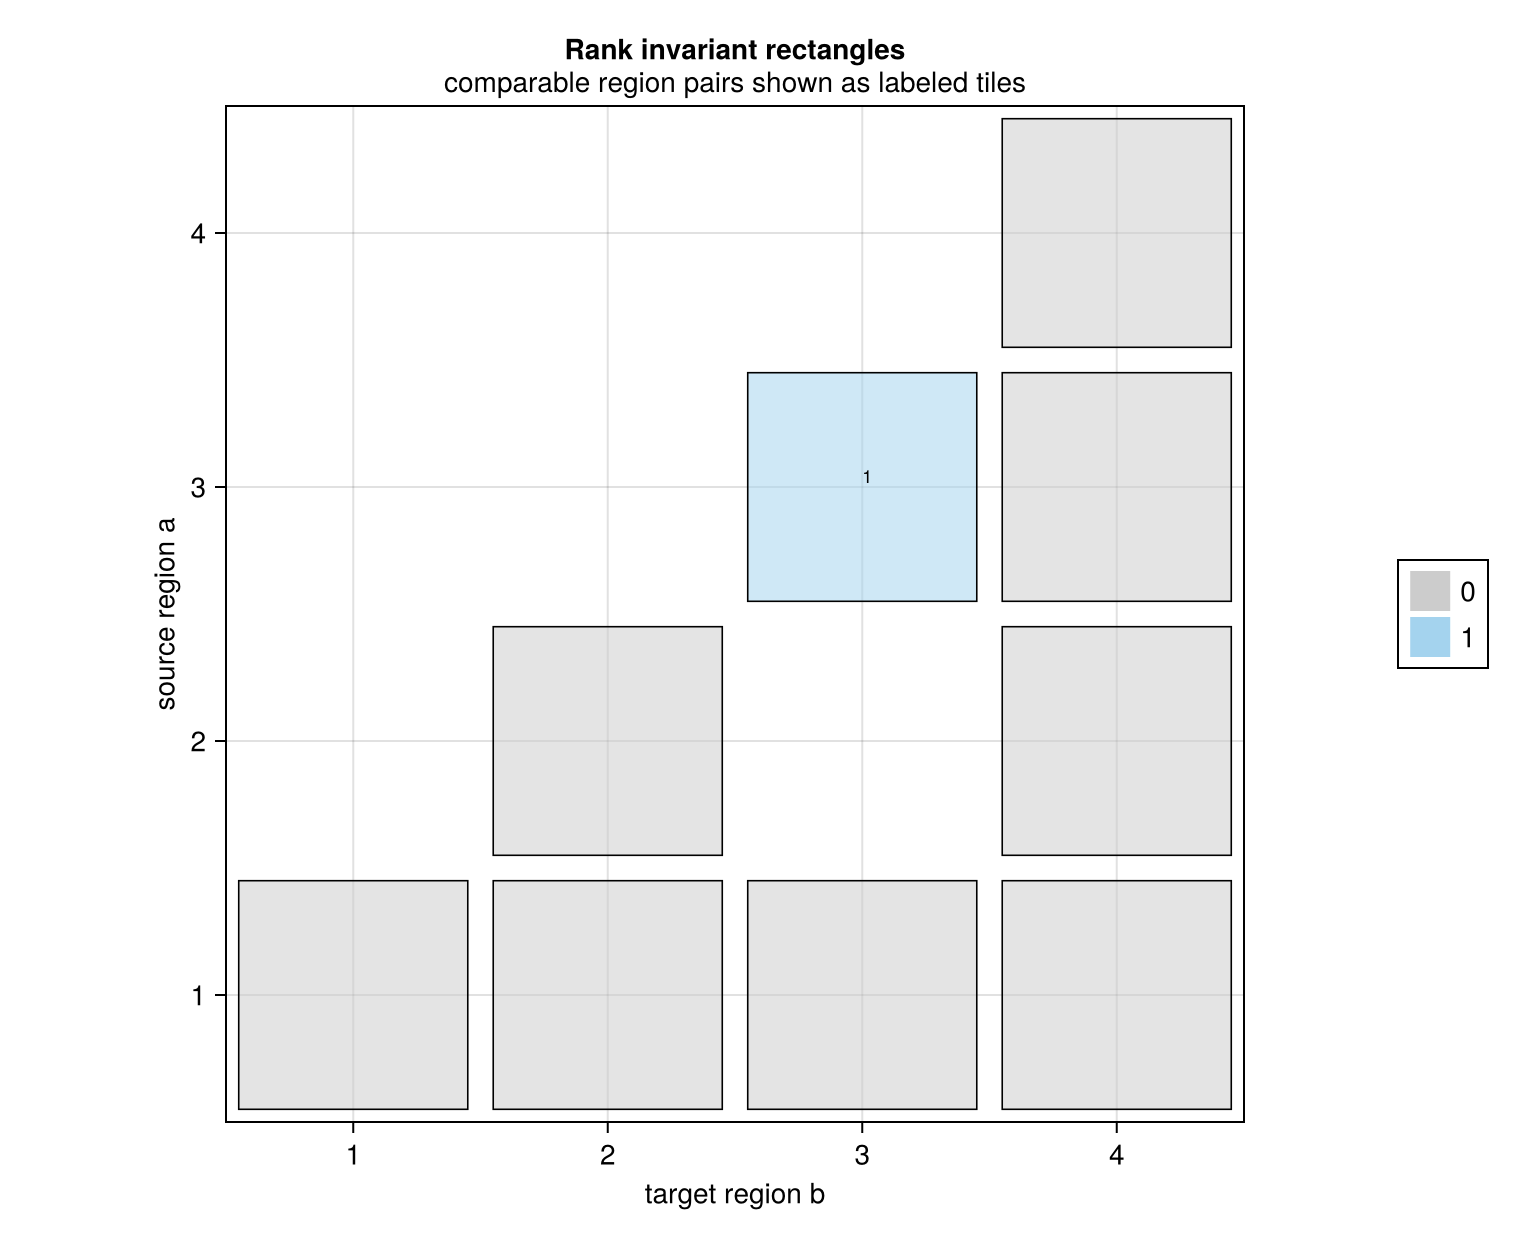

In [10]:
TO.visualize(rank; kind=:rank_rectangles, backend=:cairomakie)

#TO.visualize(rank_spec; backend=:cairomakie)

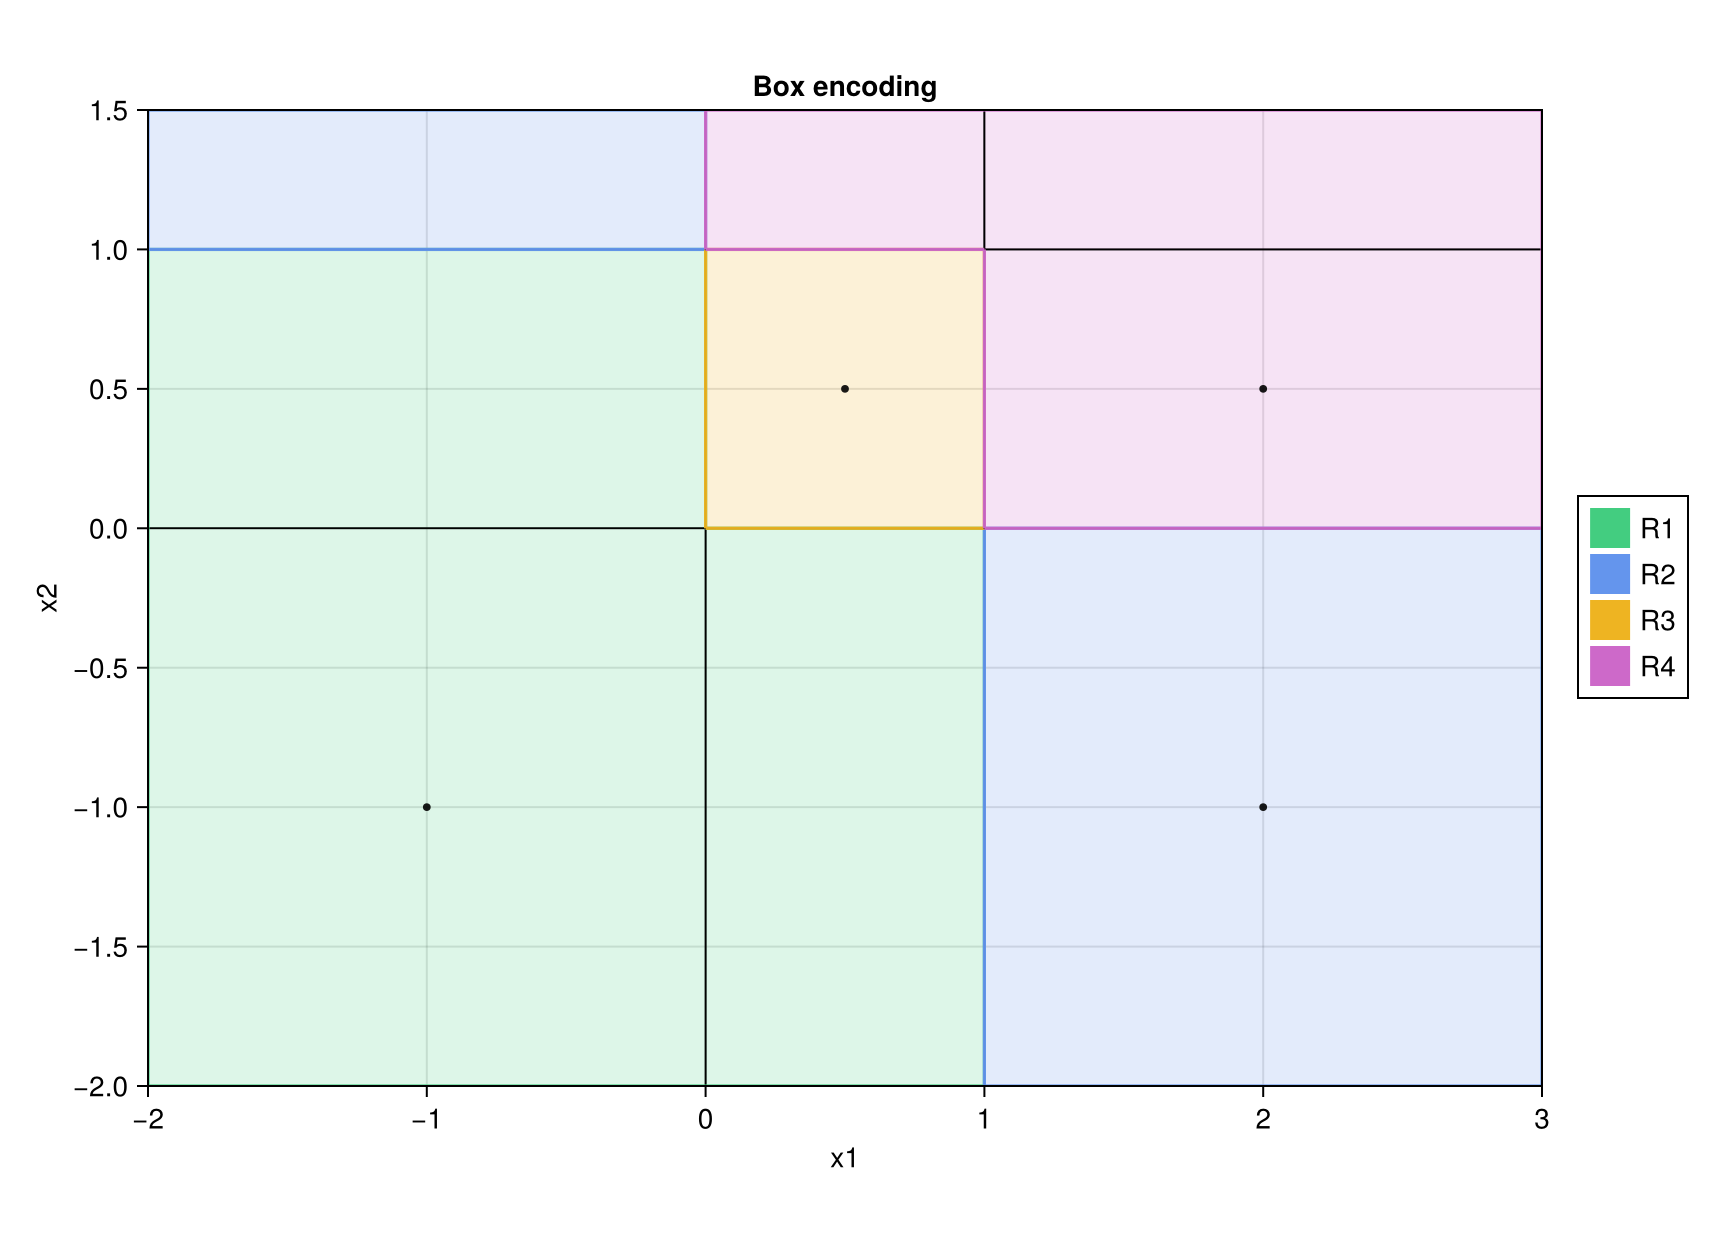

In [11]:
TO.visualize(pi; kind=:regions, backend=:cairomakie)

#TO.visualize(region_spec; backend=:cairomakie)


## 4. Export the same visuals to disk

This is the canonical export path. Here we export lightweight HTML visual-spec artifacts so the cell stays deterministic on participant laptops while still teaching `save_visuals(...)` directly.


In [12]:
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "combinatorial_cowork_2026", NOTEBOOK_STEM)
mkpath(outdir)


exports = TO.save_visuals(
    outdir,
    [
        (; stem="kernel_smoke_regions", obj=pi, kind=:regions),
        (; stem="kernel_smoke_rank_heatmap", obj=rank, kind=:rank_heatmap),
    ];
    format=:png,
    backend=:cairomakie,
)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)

Dict{String, String} with 2 entries:
  "kernel_smoke_rank_heatmap" => "/home/eriknovak/Documents/duke_fall_2025/tame…
  "kernel_smoke_regions"      => "/home/eriknovak/Documents/duke_fall_2025/tame…

## Try this next

Add a second bar and rerun the encoding, invariant, and export cells.

In [13]:
box_two = SD.box_bar_fringe(
    bars=[([0.0, 0.0], [1.0, 1.0]), ([0.5, 0.5], [1.5, 1.5])],
)

#enc_two = TO.encode(box_two; cache=sc)
#rank_two = TO.rank_invariant(enc_two; opts=opts, cache=sc)

enc_two = TO.encode(box_two)
rank_two = TO.rank_invariant(enc_two)


(; box_two_summary=TO.describe(box_two),
   encoding_two_summary=TO.describe(enc_two),
   rank_two_summary=TO.describe(rank_two))

(box_two_summary = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, matrix_size = (2, 2), field = TamerOp.CoreModules.CoeffFields.QQField()), encoding_two_summary = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0, 1, 0, 0, 2, 1, 0]), rank_two_summary = (kind = :rank_invariant, nentries = 5, nnonzero = 5, store_zeros = false, nvertices = 9, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}))

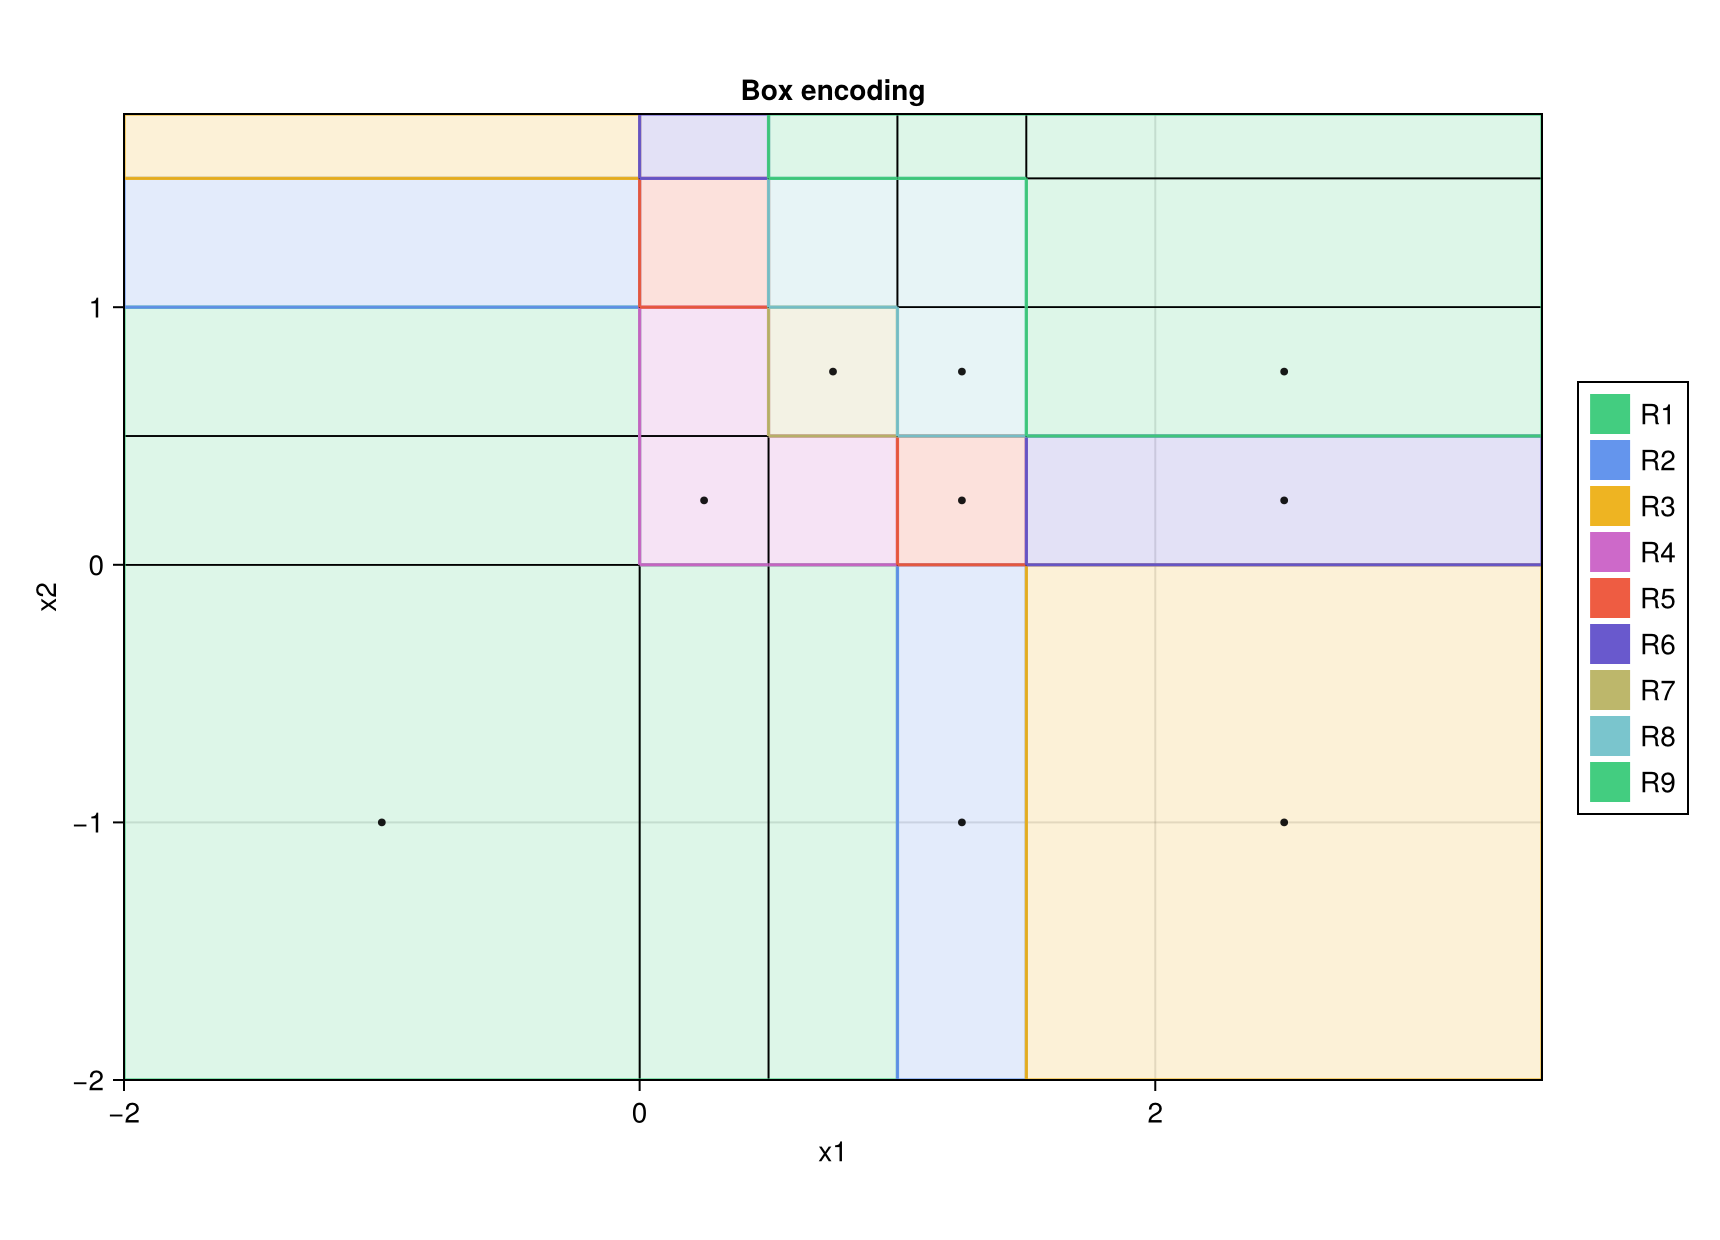

In [14]:
TO.visualize(TO.encoding_map(enc_two); kind=:regions, backend=:cairomakie)

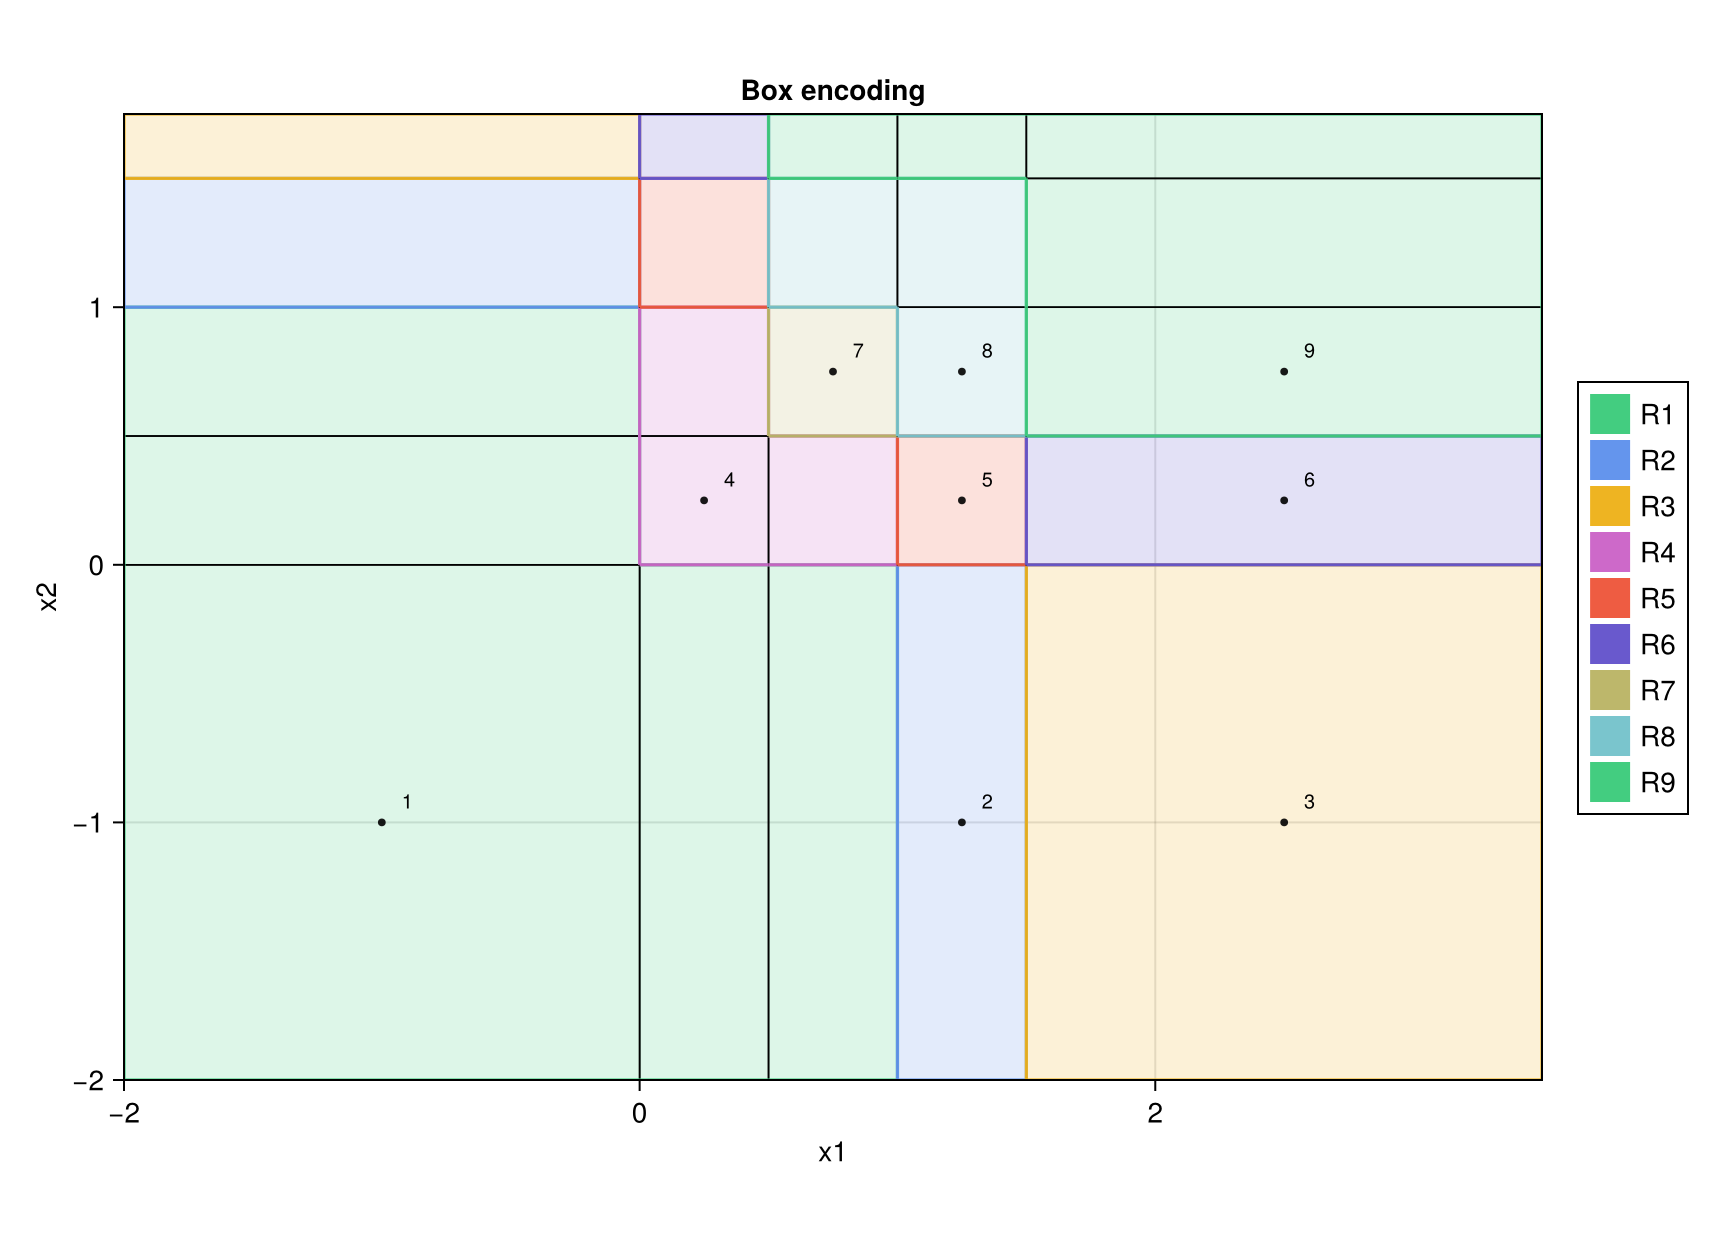

In [15]:
TO.visualize(TO.encoding_map(enc_two); kind=:region_labels, backend=:cairomakie)

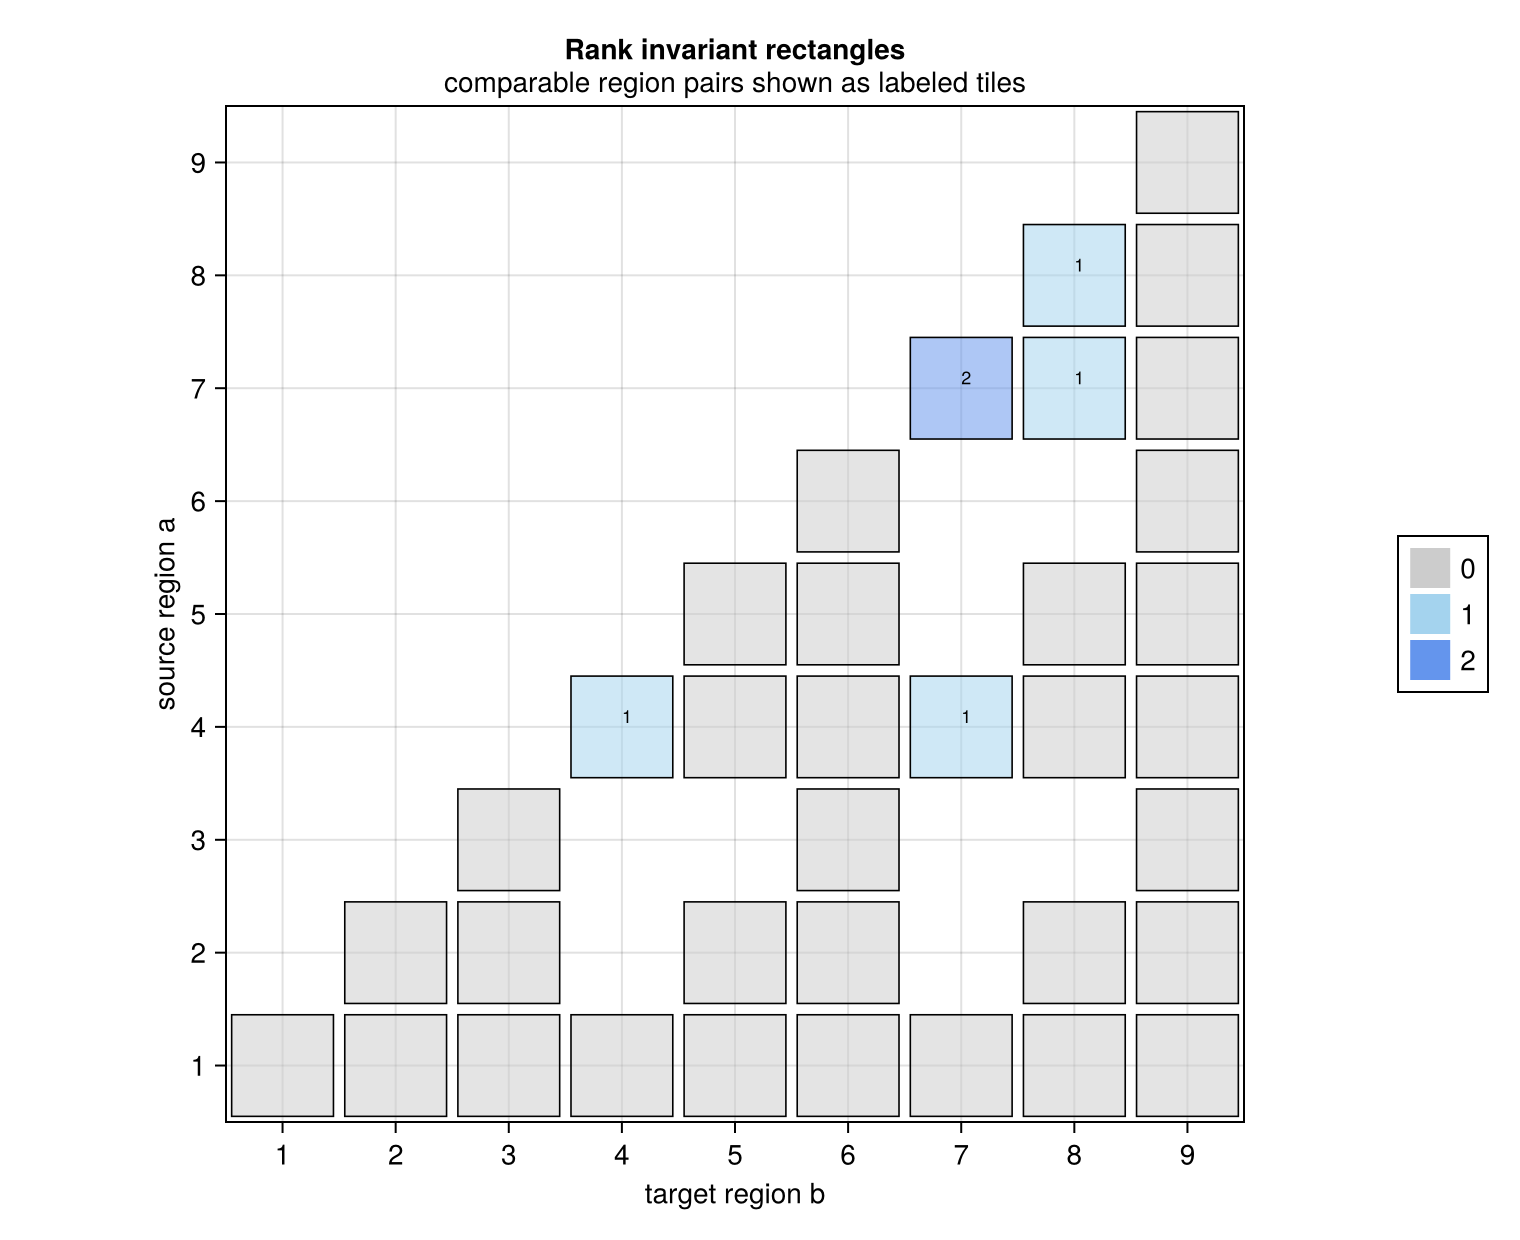

In [16]:
TO.visualize(rank_two; kind=:rank_rectangles, backend=:cairomakie)